Our cleaned NERIS dataset allows us to further explore some aspects of the incident reporting that we may be interested in. A few high-level trends and analyses we can perform include breaking down incident types, frequency of incidents by time of day and day of week, the number of units that typically respond to a call, and a coordinate-based plot to see if we can identify any clustering of incidents in major areas/cities.

In [42]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and check data
data = pd.read_csv('data/neris_cleaned.csv')
print(data.shape)
data.head(3)

(2239, 10)


,neris_id_incident,department_name,type_1_main,call_create_eastern,hour,day_of_week,time_period,unit_response_count,x,y
0,FD24013403|26000015_639029121620263116|1767268001,Carroll County Department of Fire & EMS,HAZSIT,2026-01-01 01:46:41-05:00,1,Thursday,overnight,1,-77.14784,39.67685
1,FD24013403|26000016_639029125507698572|1767268508,Carroll County Department of Fire & EMS,MEDICAL,2026-01-01 01:55:08-05:00,1,Thursday,overnight,1,-77.21292,39.65774
2,FD24013403|26000024_639029639910136704|1767280610,Carroll County Department of Fire & EMS,MEDICAL,2026-01-01 05:16:50-05:00,5,Thursday,overnight,1,-77.15879,39.65046


Our clean dataset is loaded, so let's begin by seeing incident type breakdowns

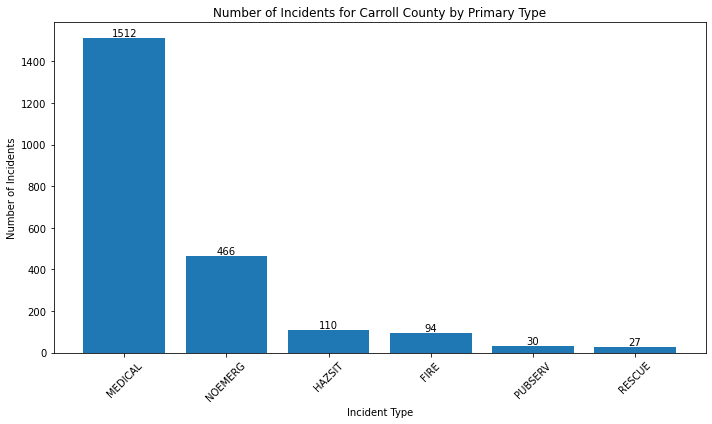

In [56]:
# Get counts of incidents by incident type and plot
fig, ax = plt.subplots(figsize=(10, 6))
counts = data['type_1_main'].value_counts()
ax.bar(counts.index, counts.values)
ax.bar_label(ax.containers[0])
ax.set_xlabel('Incident Type')
ax.set_ylabel('Number of Incidents')
ax.set_title('Number of Incidents for Carroll County by Primary Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this we can see the vast majority of incidents are primarily Medical for the current year, with the next closest category having almost 1000 less incidents (No Emergency).

Now let's see if there are any trends based on day of week or time of day.

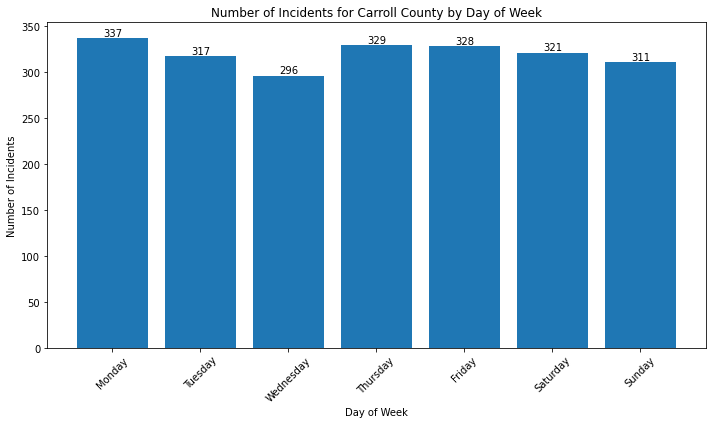

In [59]:
# Group by and order day of week
day_counts = data['day_of_week'].value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(day_order)

# Get number of incidents by day of week and plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(day_counts.index, day_counts.values)
ax.bar_label(ax.containers[0])
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Incidents')
ax.set_title('Number of Incidents for Carroll County by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Incidents by day of week are roughly comparable, with Mondays seeing the highest number this year and Wednesdays seeing the lowest.

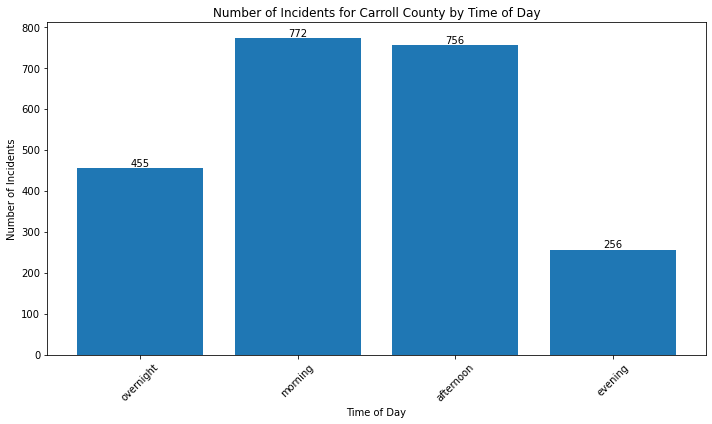

In [60]:
# Group by and order time of day
time_counts = data['time_period'].value_counts()
time_order = ['overnight', 'morning', 'afternoon', 'evening']
time_counts = time_counts.reindex(time_order)

# Get number of incidents by time of day and plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(time_counts.index, time_counts.values)
ax.bar_label(ax.containers[0])
ax.set_xlabel('Time of Day')
ax.set_ylabel('Number of Incidents')
ax.set_title('Number of Incidents for Carroll County by Time of Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Morning (6a-12p) and Afternoon (12p-6p) have many more incidents than Overnight (12a-6a) and Evening (6p-12a) periods.

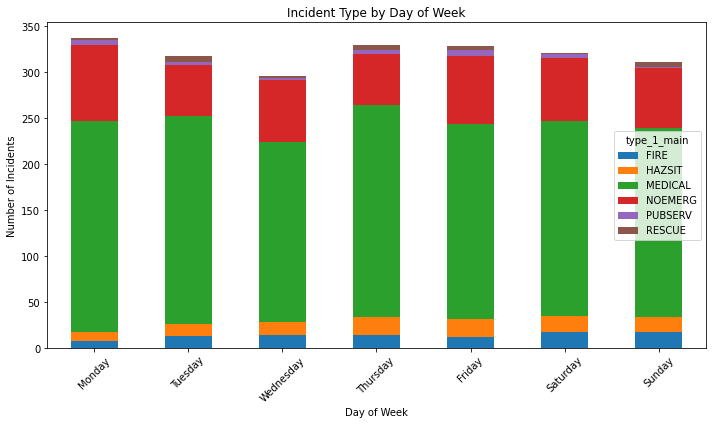

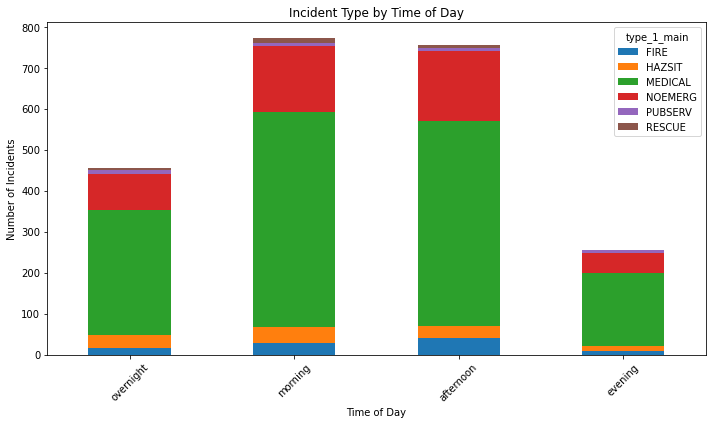

In [65]:
# Let's plot stacked bars now to get a bit more info
incident_by_day = pd.crosstab(data['day_of_week'], data['type_1_main'])
incident_by_day = incident_by_day.reindex(day_order)
incident_by_time = pd.crosstab(data['time_period'], data['type_1_main'])
incident_by_time = incident_by_time.reindex(time_order)

fig, ax = plt.subplots(figsize=(10, 6))
incident_by_day.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Incidents')
ax.set_title('Incident Type by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
incident_by_time.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Time of Day')
ax.set_ylabel('Number of Incidents')
ax.set_title('Incident Type by Time of Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This honestly doesn't show us a whole lot more than we already know, but it was worth checking out to look for any additional patterns.

Another thing we can check out is unit response count, as a whole and broken down by incident type.

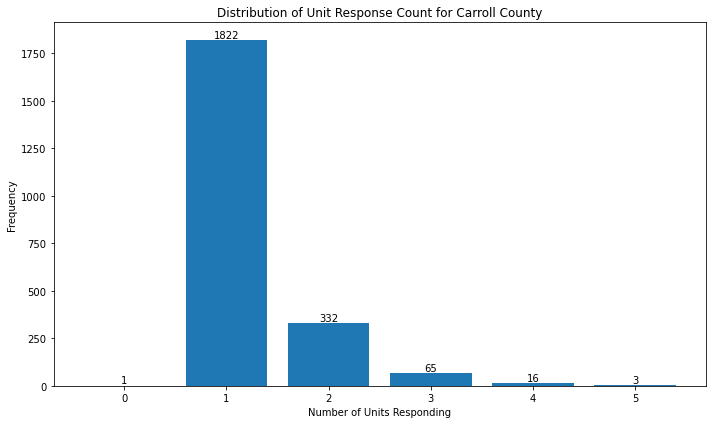

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
unit_counts = data['unit_response_count'].value_counts().sort_index()
ax.bar(unit_counts.index, unit_counts.values)
ax.bar_label(ax.containers[0])
ax.set_xlabel('Number of Units Responding')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Unit Response Count for Carroll County')
plt.tight_layout()
plt.show()

The vast majority of incidents had only 1 unit respond. Interestingly, there was an incident that had 0 units respond, which may warrant further investigation.

In [41]:
print(data[data['unit_response_count']==0])

                                      neris_id_incident  \
1141  FD24013403|26007474_639124257905799877|1776822494   

                              department_name type_1_main  \
1141  Carroll County Department of Fire & EMS     NOEMERG   

            call_create_eastern  hour day_of_week time_period  \
1141  2026-04-21 17:48:14-04:00    17     Tuesday   afternoon   

      unit_response_count         x         y  
1141                    0 -76.91278  39.51878  


Here is that particular incident, which happened to be a NOEMERG.

Finally, let's make a simple plot of x/y corrdinates to see if there are any clusters of activity.

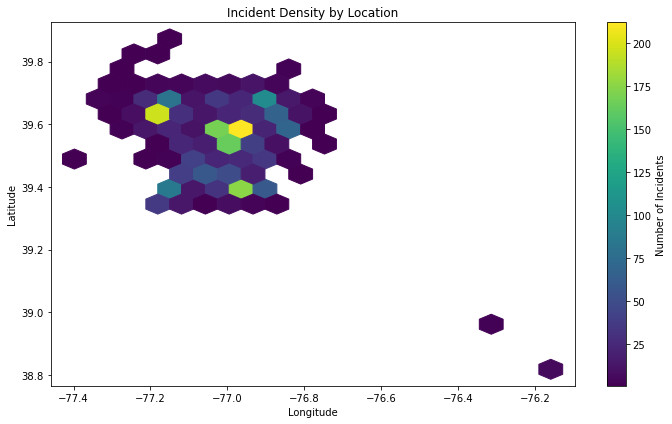

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(data['x'], data['y'], gridsize=20, cmap='viridis', mincnt=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Incident Density by Location')
cbar = plt.colorbar(hb, ax=ax, label='Number of Incidents')
plt.tight_layout()
plt.show()

We can see there are a few clusters of higher incident rates based on the greens/yellows on this coordinate map. If we look at a map of Carroll County, we can see the educated guess that these probably correspond with the cities of Westminster (central), Taneytown (northwest), and perhapd Eldersburg (southeast).